# HW 15 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 9th, 2025 at 11:59pm** on Gradescope

## 1 Modify the Animation from Lecture
Modify the given sine wave animation so that the wave moves twice as fast. What parts of the code you you need to change, and why? Please specifically highlight this in your code

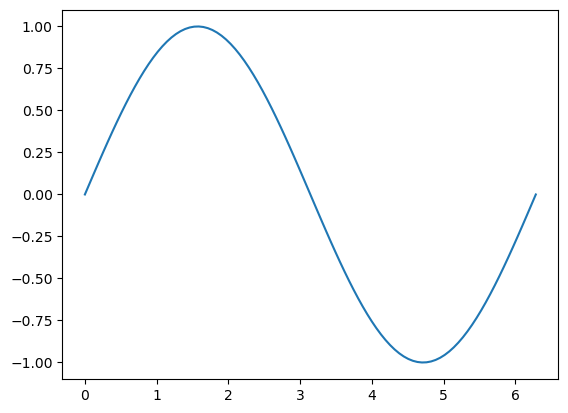

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots()
x = np.linspace(0, 2*np.pi, 100)
line, = ax.plot(x, np.sin(x))
def update(frame):
    """
    Updates the sine wave to shift horizontally.
    frame(int) = current frame number, increases with time
    line, (tuple) = the updated line object that is being redrawn
    """
    line.set_ydata(np.sin(x + 2 * frame / 10.0)) # I only changed this line: now each frame, it moves twice as much as before
    return line,

ani = animation.FuncAnimation(fig, update, frames=100, interval=50, blit=True)
plt.show()

In [ ]:
# The only thing I changed was that in every frame, the sine wave gets shifted by twice as much

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [5]:
ani.save("sinewave2x.gif", writer="pillow", fps=20)

Explain what happens if you set `blit=True` in `FuncAnimation`? What happens if you set it to `blit=False`?

In [ ]:
# blit = True means that the parts of the frame that are not changed are saved for the next frame (to save computation time). If blit = False, it will
# generate the next frame independently from the previous one.

## 2 A Different Animation
Write an animation where a dot moves in a circular path instead of sine wave. *Hint: You will need to use `np.sin` and `np.cos`. 

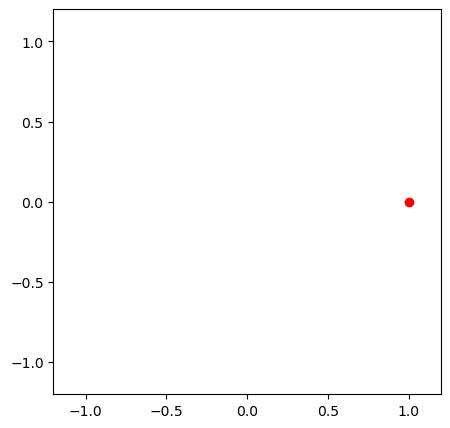

In [23]:
theta = [0]
fig, ax = plt.subplots(figsize=(5, 5))
line, = ax.plot(np.cos(theta), np.sin(theta), 'ro')
def update(frame):
    line.set_ydata(np.sin([theta[0] + frame / 10.0]))
    line.set_xdata(np.cos([theta[0] + frame / 10.0]))
    return line,
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
ani = animation.FuncAnimation(fig, update, frames=100, interval = 50, blit = True)

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [24]:
ani.save("circle.gif", writer="pillow", fps=20)
plt.show()

## 3 Simulate Orbital Motion of Planets and a Comet
**Check out the `example_solar_system_animation.mp4` as an example of what you will be creating in this problem.**

Now you will simulate and visualize the orbital motion of Earth, Mars and a coment around the Sun using Newtonian gravity and Python. Here are the steps:
* Calculate the gravitational forces acting on each body.
* Update positions and velocities over time.
* Simulate the motion of these celestial bodies over a period of 5 years.
* Animate the results to observe orbital patterns. 

Let's dig a bit into the physics. The motion of celestial bodies follows **Newton's laws of motion and gravitation**:
$$
F = G \frac{m_1 m_1}{r^2}
$$

where:
* $F$ is the gravitational force.
* $G = 6.67\times10^{-11}$ is the gravitational constant
* $m_1$, $m_2$ are the measses of the two objects.
* $r$ is the distance between them.

Using **Newton's Second Law**, the acceleration is given by:

$$
a = \frac{F}{m}
$$

where $a$ is the acceleration, and $m$ is the object's mass. The velocity and position are updated with numerical integration:

$$
v = v + a \cdot dt
$$

$$
x = x + v \cdot dt
$$

## 3.1 Implementing the Simulation
Goal: Set up the **masses**, **initial positions** and **velocities** for the Sun, Earth, Mars and a comet. 
* Use SI units (meters, kilograms, seconds).
* The Sun is at the origin (0, 0, 0)
* Earth, Mars and the commet start at **aphelion** (farthest from the Sun).

Start by defining the following initial variables in kilograms (or SI units):
* `G`
* `Ms` (the mass of the Sun, you will need to google this)
* `Me` (the mass of the Earth)
* `Mm` (the mass of Mars)
* `Mc = 6.39e20` (the mass of a comet)
* `AU` (astronomical unit, distance between Earth and the Sun)
* `daysec` (how many seconds are in a day)

In [23]:
G = 6.67 * 10**(-11)
Ms = 1.9891 * 10**30
Me = 5.972 * 10**24
Mm = 6.39 * 10**23
Mc = 6.39 * 10**20
AU = 1.5 * 10**11
daysec = 86400

Now we will define some initial velocities in meters per second:
* `e_ap_v` (Earth at aphelion, google it, make sure its in SI units)
* `m_ap_v` (Mars at aphelion)
* `commet_v = 7000` (speed of the comet)

In [24]:
e_ap_v = 2.93 * 10**4
m_ap_v = 2.197 * 10**4
commet_v = 7000

Run the cell below to define some gravitational constants because we expect no mass loss:

In [27]:
# Your code here

Define the initial positions of the Earth, Mars and the comet. Here is the Earth as an example:
* `xe, ye, ze = 1.0167 * AU, 0, 0`

Follow the same pattern for Mars (where the `x` coordinate is at `1.666 * AU`, everything else is zero) and the comet (where the `x` coordinate is at `2* AU`, the `y` coordinate is `0.3 * AU` and the `z` coordinate is zero) . Remember the sun is at the origin! 

In [25]:
xe, ye, ze = 1.0167 * AU, 0, 0
xm, ym, zm = 1.666 * AU, 0, 0
xc, yc, zc = 2 * AU, 0.3 * AU, 0

We will do the same thing but for initial velocities. Here is Earth as an example:
* `xve, yve, zve = 0, e_ap_v, 0`

Make variables for Mars but with `m_ap_v` as the `y` coordinate. Make variables for the commet but with `commet_v` as the `y` coordinate.

In [26]:
xve, yve, zve = 0, e_ap_v, 0
xvm, yvm, zvm = 0, m_ap_v, 0
xvc, yvc, zvc = 0, commet_v, 0

Assume the Sun is at the origin. Make initial positions and velocities for the Sun. It should not be moving so all its velocities coordinates are zero. 

In [27]:
xs, ys, zs = 0, 0, 0
xvs, yvs, zvs = 0, 0, 0

Now we will define some time parameters for our simulation. Create variable for the initial time `t` and set it to zero. Create a variable called `dt` for the change in time (steps per day) and set it to `1 * daysec`. Create a varible for `years` and set it to `5`. Finally, create a varible for `sim_years` and set it equal to `years * 365 * daysec`.

In [28]:
t = 0
dt = 1 * daysec
years = 5
sim_years = years * 365 * daysec

Create empty lists to store all of your varibles. Run the cell below.

In [30]:
# Store the orbits:
xelist = []
yelist = []
xmlist = []
ymlist = []
xslist = []
yslist = []
xclist = []
yclist = []

## 3.2 Compute Gravitational Forces and Update Positions
Goal:
* Implement the **gravitational force equation** to calculate the force acting on each body.
* Compute accelerations using $a = F/m$.
* Update **velocity** and **position**.
* Use a loop to update positions over **5 years**.
* Store the results in lists for plotting.

I will do this part for you, it requires some physics knowledge. But you need to turn this into a loop for when time is less than the simulation time. You want the loop to repeat it itself until that condition is met. 

In [31]:
# Your code here
t = 0
while t <= sim_years:
    ################ Earth #############
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -G * Me * Ms * rx / modr3_e
    fy_e = -G * Me * Ms * ry / modr3_e
        
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
        
    xelist.append(xe)
    yelist.append(ye)
    
    ################ Mars ##############
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -G * Mm * Ms * rx_m / modr3_m
    fy_m = -G * Mm * Ms * ry_m / modr3_m
        
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
        
    xmlist.append(xm)
    ymlist.append(ym)
    
    ################ Comet ##############
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -G * Mc * Ms * rx_c / modr3_c
    fy_c = -G * Mc * Ms * ry_c / modr3_c
        
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
        
    xclist.append(xc)
    yclist.append(yc)
    
    ################ Sun ##############
    xvs += -(fx_e + fx_m) * dt / Ms
    yvs += -(fy_e + fy_m) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    xslist.append(xs)
    yslist.append(ys)
    
    t += dt

## 3.3 Visualization
Goal: Plot the Orbits
* After simulating the motion, **plot the orbits of Earth, Mars and the comet**.
* Label the **Sun**, **Earth**, **Mars**, and **Comet**.

Start by making a figure, set the argument of`figsize=(8, 8)`.
* Plot the `yelist` as a function of `xelist`. Do this for the `xm`, `xc` and `xs` lists as well. Make sure each line is a **different color**!
  * The Sun will just be a point, so give it a markersize of `10`. Make it yellow.  
* Give it a legend
* Add an `xlabel` of `"X Position (m)"`.
* Add an `ylabel` of `"Y Position (m)"`.
* Give it a title.
* Add a grid.
* Show the plot.

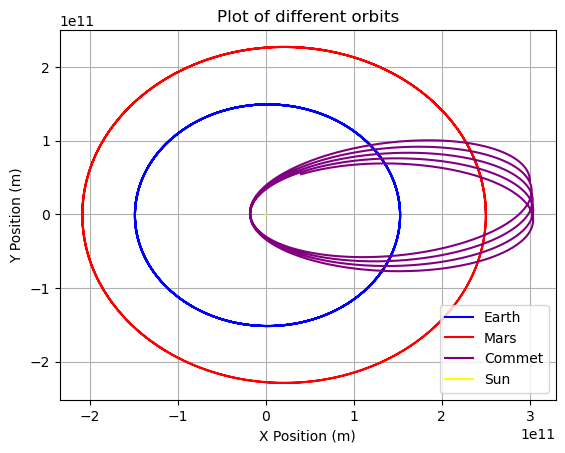

In [32]:
plt.plot(xelist, yelist, color='blue', label="Earth")
plt.plot(xmlist, ymlist, color='red', label="Mars")
plt.plot(xclist, yclist, color='purple', label="Commet")
plt.plot(xslist, yslist, ms=10, color='yellow', label="Sun")
plt.title("Plot of different orbits")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.grid()
plt.legend()
plt.show()

Goal: Animate the Motion
* Create an animated visualization of planetary orbits.
* Track the motion of each body over time.

\
Follow the procedure from lecture. Here are some hints:
* Set the `x` and `y` limits to `-3 * AU` to `3 * AU`. \


* Unpack the lines for Earth, Mars, the commet. Example: 
  * `line_e = axplot([], [], '-g', lw=1)` \

  
* Unpack the points for Earth, Mars, the commet and the Sun. Example:
  * `point_e, = ax.plot([],[],'bo',markersize=4)` \

* Give a title to each of the objects. Example:
  * `text_e  = ax.text(AU,0,'Earth')`

* Create the `update` function and update the lines, points and text you just unpacked. Example:
  * `line_e.set_data(xelist[:i], yelist[:i])` 
  * `point_e.set_data(xelist[i], yelist[i])`\
  * `text_e.set_position((xelist[i],yelist[i]))`


* Create the animation! Set `frames = len(xelist)`, `interval=1` and `blit=True`. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\lboui\AppData\Local\Temp\ipykernel_159220\3865381136.py:27: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_e.set_data(xelist[i], yelist[i])
C:\Users\lboui\AppData\Local\Temp\ipykernel_159220\3865381136.py:31: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_m.set_data(xmlist[i], ymlist[i])
C:\Users\lboui\AppData\Local\Temp\ipykernel_159220\3865381136.py:35: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_s.set_data(xslist[i], yslist[i])
C:\Users\lboui\AppData\Local\Temp\ipykernel_159220\3865381136.py:39: MatplotlibDeprecationWarning: Settin

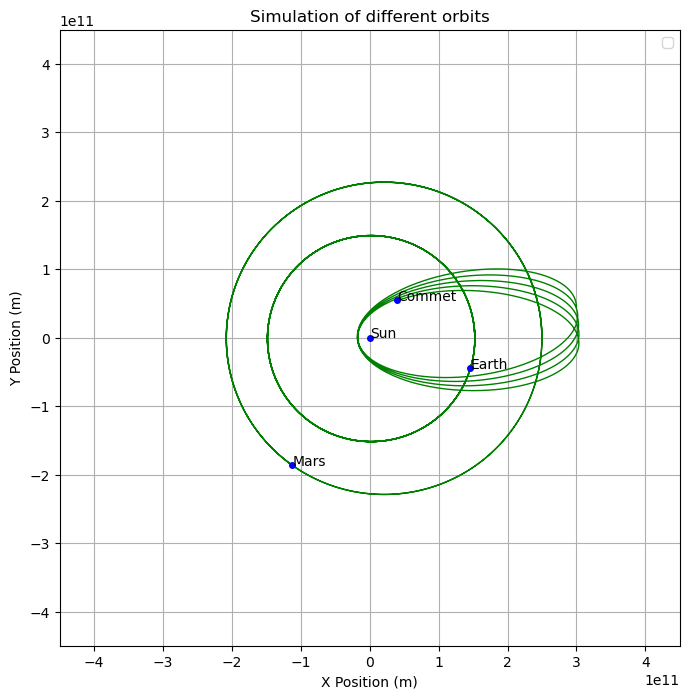

In [42]:
fig, ax = plt.subplots(figsize=(8,8))
line_e, = ax.plot([], [], '-g', lw=1, color='blue')
point_e, = ax.plot([],[],'bo',markersize=4)
text_e  = ax.text(0.5,0,'Earth')

line_m, = ax.plot([], [], '-g', lw=1, color='red')
point_m, = ax.plot([],[],'bo',markersize=4)
text_m  = ax.text(0.5,0,'Mars')

line_s, = ax.plot([], [], '-g', lw=1, color='yellow')
point_s, = ax.plot([],[],'bo',markersize=4)
text_s  = ax.text(0.5,0,'Sun')

line_c, = ax.plot([], [], '-g', lw=1, color='purple')
point_c, = ax.plot([],[],'bo',markersize=4)
text_c  = ax.text(0.5,0,'Commet')
plt.title("Simulation of different orbits")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.grid()
plt.legend()
plt.xlim(-3 * AU, 3 * AU)
plt.ylim(-3 * AU, 3 * AU)
def update(i):
    line_e.set_data(xelist[:i], yelist[:i])
    point_e.set_data(xelist[i], yelist[i])
    text_e.set_position((xelist[i],yelist[i]))

    line_m.set_data(xmlist[:i], ymlist[:i])
    point_m.set_data(xmlist[i], ymlist[i])
    text_m.set_position((xmlist[i],ymlist[i]))

    line_s.set_data(xslist[:i], yslist[:i])
    point_s.set_data(xslist[i], yslist[i])
    text_s.set_position((xslist[i],yslist[i]))

    line_c.set_data(xclist[:i], yclist[:i])
    point_c.set_data(xclist[i], yclist[i])
    text_c.set_position((xclist[i],yclist[i]))
    
    return line_e, point_e, text_e, line_m, point_m, text_m, line_s, point_s, text_s, line_c, point_c, text_c
ani = animation.FuncAnimation(fig, update, frames=len(xelist), interval = 1, blit = True)
ani.save("planetsorbit.gif", writer="pillow", fps=20)
plt.show()

## 3.4 Add Mercury, Venus and the Moon!
As an extra challenge, give your best attempt at simulating Mercury, Venus and/or the Moon! I am not going to give you a ton of hints for this problem. Come to office hours if you have questions :)

C:\Users\lboui\AppData\Local\Temp\ipykernel_159220\2935926980.py:156: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-g" (-> color='g'). The keyword argument will take precedence.
  line_e, = ax.plot([], [], '-g', lw=1, color='blue')
C:\Users\lboui\AppData\Local\Temp\ipykernel_159220\2935926980.py:160: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-g" (-> color='g'). The keyword argument will take precedence.
  line_m, = ax.plot([], [], '-g', lw=1, color='red')
C:\Users\lboui\AppData\Local\Temp\ipykernel_159220\2935926980.py:164: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-g" (-> color='g'). The keyword argument will take precedence.
  line_s, = ax.plot([], [], '-g', lw=1, color='yellow')
C:\Users\lboui\AppData\Local\Temp\ipykernel_159220\2935926980.py:168: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt 

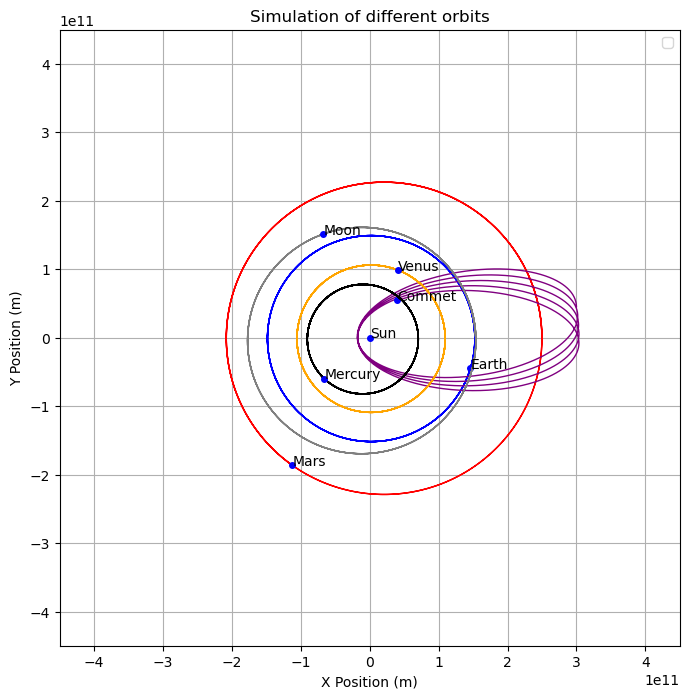

NameError: name 'anim' is not defined

In [53]:
G = 6.67 * 10**(-11)
Ms = 1.9891 * 10**30
Me = 5.972 * 10**24
Mm = 6.39 * 10**23
Mc = 6.39 * 10**20
Mme = 3.285 * 10**23
Mv = 4.867*10**24
Mmo = 7.35*10**22
AU = 1.5 * 10**11
daysec = 86400

e_ap_v = 2.93 * 10**4
m_ap_v = 2.197 * 10**4
commet_v = 7000
me_ap_v = 4.6 * 10**4
v_ap_v = 3.45 * 10**4
mo_ap_v = 1.02 * 10**3 + e_ap_v

xe, ye, ze = 1.0167 * AU, 0, 0
xm, ym, zm = 1.666 * AU, 0, 0
xc, yc, zc = 2 * AU, 0.3 * AU, 0
xme, yme, zme = 0.47 * AU, 0, 0
xv, yv, zv = 0.73 * AU, 0, 0
xmo, ymo, zmo = xe + 0.002569 * AU, 0, 0

xve, yve, zve = 0, e_ap_v, 0
xvm, yvm, zvm = 0, m_ap_v, 0
xvc, yvc, zvc = 0, commet_v, 0
xs, ys, zs = 0, 0, 0
xvs, yvs, zvs = 0, 0, 0
xvme, yvme, zvme = 0, me_ap_v, 0
xvv, yvv, zvv = 0, v_ap_v, 0
xvmo, yvmo, zvmo = 0, mo_ap_v, 0

t = 0
dt = 1 * daysec
years = 5
sim_years = years * 365 * daysec

xelist = []
yelist = []
xmlist = []
ymlist = []
xslist = []
yslist = []
xclist = []
yclist = []
xmelist = []
ymelist = []
xvlist = []
yvlist = []
xmolist = []
ymolist = []

t = 0
while t <= sim_years:
    ################ Earth #############
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -G * Me * Ms * rx / modr3_e
    fy_e = -G * Me * Ms * ry / modr3_e
        
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
        
    xelist.append(xe)
    yelist.append(ye)
    
    ################ Mars ##############
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -G * Mm * Ms * rx_m / modr3_m
    fy_m = -G * Mm * Ms * ry_m / modr3_m
        
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
        
    xmlist.append(xm)
    ymlist.append(ym)
    
    ################ Comet ##############
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -G * Mc * Ms * rx_c / modr3_c
    fy_c = -G * Mc * Ms * ry_c / modr3_c
        
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
        
    xclist.append(xc)
    yclist.append(yc)
    
    ################ Sun ##############
    xvs += -(fx_e + fx_m) * dt / Ms
    yvs += -(fy_e + fy_m) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    xslist.append(xs)
    yslist.append(ys)

    ################ Mercury #############
    rx_me, ry_me, rz_me = xme - xs, yme - ys, zme - zs
    modr3_me = (rx_me**2 + ry_me**2 + rz_me**2)**1.5
    fx_me = -G * Mme * Ms * rx_me / modr3_me
    fy_me = -G * Mme * Ms * ry_me / modr3_me
        
    xvme += fx_me * dt / Mme
    yvme += fy_me * dt / Mme
    xme += xvme * dt
    yme += yvme * dt
        
    xmelist.append(xme)
    ymelist.append(yme)

    ################ Venus #############
    rx_v, ry_v, rz_v = xv - xs, yv - ys, zv - zs
    modr3_v = (rx_v**2 + ry_v**2 + rz_v**2)**1.5
    fx_v = -G * Mv * Ms * rx_v / modr3_v
    fy_v = -G * Mv * Ms * ry_v / modr3_v
        
    xvv += fx_v * dt / Mv
    yvv += fy_v * dt / Mv
    xv += xvv * dt
    yv += yvv * dt
        
    xvlist.append(xv)
    yvlist.append(yv)

    ################ Moon #############
    rx_mo, ry_mo, rz_mo = xmo - xs, ymo - ys, zmo - zs
    rx_mo_e, ry_mo_e, rz_mo_e = xmo - xe, ymo - ye, zmo - ze
    modr3_mo = (rx_mo**2 + ry_mo**2 + rz_mo**2)**1.5
    modr3_mo_e = (rx_mo_e**2 + ry_mo_e**2 + rz_mo_e**2)**1.5
    fx_mo = -G * Mmo * Ms * rx_mo / modr3_mo
    fy_mo = -G * Mmo * Ms * ry_mo / modr3_mo
    fx_mo_e = -G * Mmo * Me * rx_mo_e / modr3_mo_e
    fy_mo_e = -G * Mmo * Me * ry_mo_e / modr3_mo_e
        
    xvmo += (fx_mo + fx_mo_e) * dt / Mmo
    yvmo += (fy_mo + fy_mo_e) * dt / Mmo
    xmo += xvmo * dt
    ymo += yvmo * dt
        
    xmolist.append(xmo)
    ymolist.append(ymo)    
    
    t += dt

fig, ax = plt.subplots(figsize=(8,8))
line_e, = ax.plot([], [], '-g', lw=1, color='blue')
point_e, = ax.plot([],[],'bo',markersize=4)
text_e  = ax.text(0.5,0,'Earth')

line_m, = ax.plot([], [], '-g', lw=1, color='red')
point_m, = ax.plot([],[],'bo',markersize=4)
text_m  = ax.text(0.5,0,'Mars')

line_s, = ax.plot([], [], '-g', lw=1, color='yellow')
point_s, = ax.plot([],[],'bo',markersize=4)
text_s  = ax.text(0.5,0,'Sun')

line_c, = ax.plot([], [], '-g', lw=1, color='purple')
point_c, = ax.plot([],[],'bo',markersize=4)
text_c  = ax.text(0.5,0,'Commet')

line_me, = ax.plot([], [], '-g', lw=1, color='black')
point_me, = ax.plot([],[],'bo',markersize=4)
text_me  = ax.text(0.5,0,'Mercury')

line_v, = ax.plot([], [], '-g', lw=1, color='orange')
point_v, = ax.plot([],[],'bo',markersize=4)
text_v  = ax.text(0.5,0,'Venus')

line_mo, = ax.plot([], [], '-g', lw=1, color='gray')
point_mo, = ax.plot([],[],'bo',markersize=4)
text_mo  = ax.text(0.5,0,'Moon')

plt.title("Simulation of different orbits")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.grid()
plt.legend()
plt.xlim(-3 * AU, 3 * AU)
plt.ylim(-3 * AU, 3 * AU)
def update(i):
    line_e.set_data(xelist[:i], yelist[:i])
    point_e.set_data(xelist[i], yelist[i])
    text_e.set_position((xelist[i],yelist[i]))

    line_m.set_data(xmlist[:i], ymlist[:i])
    point_m.set_data(xmlist[i], ymlist[i])
    text_m.set_position((xmlist[i],ymlist[i]))

    line_s.set_data(xslist[:i], yslist[:i])
    point_s.set_data(xslist[i], yslist[i])
    text_s.set_position((xslist[i],yslist[i]))

    line_c.set_data(xclist[:i], yclist[:i])
    point_c.set_data(xclist[i], yclist[i])
    text_c.set_position((xclist[i],yclist[i]))

    line_me.set_data(xmelist[:i], ymelist[:i])
    point_me.set_data(xmelist[i], ymelist[i])
    text_me.set_position((xmelist[i],ymelist[i]))

    line_v.set_data(xvlist[:i], yvlist[:i])
    point_v.set_data(xvlist[i], yvlist[i])
    text_v.set_position((xvlist[i],yvlist[i]))
    
    line_mo.set_data(xmolist[:i], ymolist[:i])
    point_mo.set_data(xmolist[i], ymolist[i])
    text_mo.set_position((xmolist[i], ymolist[i]))
    
    return line_e, point_e, text_e, line_m, point_m, text_m, line_s, point_s, text_s, line_c, point_c, text_c, line_me, point_me, text_me, line_v, point_v, text_v, line_mo, point_mo, text_mo
ani = animation.FuncAnimation(fig, update, frames=len(xelist), interval = 1, blit = True)
ani.save("planetsorbitchallenge.gif", writer="pillow", fps=20)
plt.show()
anim.save("animation.mp4", writer="ffmpeg", fps=20)

Save you animation as a `.gif` or as a `.mp4`. Include this in your submission! This may take up to a couple mintutes!

In [48]:
print(np.array(xmolist[0:10]) / AU)

[1.019269   1.019269   1.01926899 1.01926899 1.01926899 1.01926898
 1.01926898 1.01926897 1.01926896 1.01926895]


In [51]:
np.allclose(np.array(xmolist[0:10]) / AU, 0.0001)

False

Upload this notebook and your animations to Gradescope!